<a href="https://colab.research.google.com/github/mkwonghsni/bengkel_daml_2026/blob/main/hari_kedua/linear_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import

In [89]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

import torch
from torch import nn

In [90]:
sns.set_theme(context="notebook", style="darkgrid")

# Menjana Data

In [91]:
rng = np.random.default_rng()

In [92]:
x = np.linspace(10, 100, 20)
X = x + rng.normal(0, 0.01, len(x))
y = x + rng.normal(0, 1, len(x))

# Fungsi

In [93]:
def melatih_model_nn(model, loss_fx, optimizer, X_latih, y_latih):
    model.train()
    y_ramal = model(X_latih.unsqueeze(1))
    loss = loss_fx(y_ramal, y_latih.unsqueeze(1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss

In [94]:
def menguji_model_nn(model, loss_fx, X_ujian, y_ujian):
    model.eval()
    with torch.inference_mode():
        y_ramal = model(X_ujian.unsqueeze(1))
        loss = loss_fx(y_ramal, y_ujian.unsqueeze(1))
    return loss

# EDA
1. Meneliti data - plot X vs y
2. Memahami shape data

In [95]:
X, y

(array([10.0019212 , 14.73196905, 19.47095398, 24.18110413, 28.9504089 ,
        33.67181865, 38.39830461, 43.15426755, 47.88718034, 52.63651994,
        57.36698633, 62.11590182, 66.83510819, 71.58705794, 76.30997484,
        81.06175577, 85.80337619, 90.5269293 , 95.26073275, 99.98726315]),
 array([10.99979766, 15.03323761, 19.33978133, 23.26020682, 28.7485639 ,
        32.32092824, 37.83010762, 44.27213711, 49.11982083, 51.15707376,
        56.31665001, 62.08058733, 65.82230523, 71.51129081, 76.22783027,
        79.47303927, 87.16280699, 90.36876564, 94.37400549, 99.26521633]))

In [96]:
X.shape, y.shape

((20,), (20,))

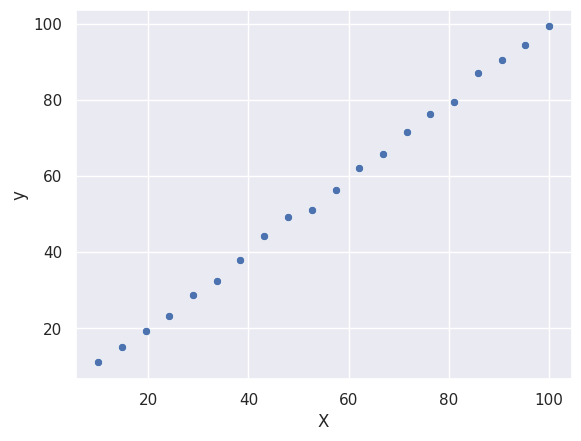

In [97]:
sns.scatterplot(x=X, y=y)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

# Regression Analysis - Conventional
1. Menggunakan kaedah statistik melalui sklearn linear regression
2. Membuat ramalan nilai y_skl_ramal
3. Mengira ralat model dengan menggunakan metrik mean absolute error
4. Memplot graf y vs y_skl_ramal

In [98]:
model_skl_lr = LinearRegression()
model_skl_lr.fit(X.reshape(-1, 1), y)

# y = mX + c
m = model_skl_lr.coef_
c = model_skl_lr.intercept_

# ramalan
y_skl_ramal = model_skl_lr.predict(X.reshape(-1, 1))

# ralat model - MAE
mae_skl_lr = mean_absolute_error(y, y_skl_ramal)

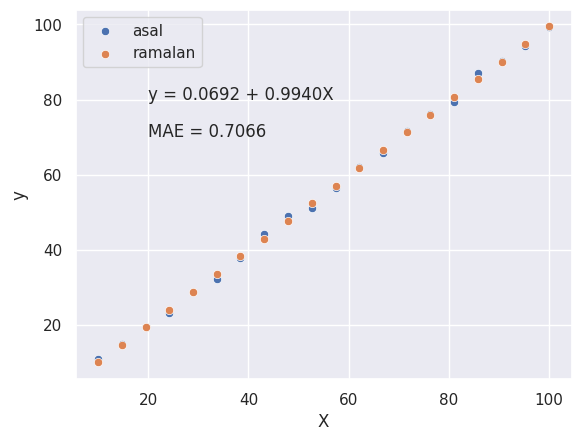

In [99]:
sns.scatterplot(x=X, y=y, label="asal")
sns.scatterplot(x=X, y=y_skl_ramal, label="ramalan")

plt.text(x=20, y=80, s=f'y = {c.item():.4f} + {m.item():.4f}X')
plt.text(x=20, y=70, s=f'MAE = {mae_skl_lr:.4f}')

plt.xlabel("X")
plt.ylabel("y")
plt.show()

# Regression Analysis - Neural Network
1. Menukarkan data daripada numpy.array kepada torch.tensor
2. Mengasingkan data kepada latihan dan ujian
3. Meneliti data - plot data latihan vs ujian
4. Membina model NN
5. Melatih model
6. Menilai model

In [100]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [101]:
X.shape, y.shape

(torch.Size([20]), torch.Size([20]))

In [102]:
X_latih, X_ujian, y_latih, y_ujian = train_test_split(X, y, test_size=0.2)

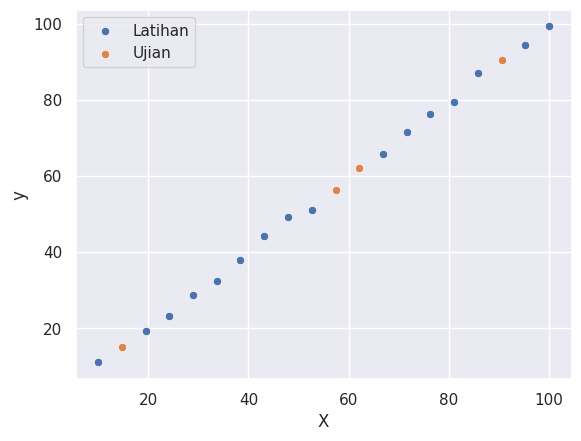

In [103]:
sns.scatterplot(x=X_latih, y=y_latih, label="Latihan")
sns.scatterplot(x=X_ujian, y=y_ujian, label="Ujian")

plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [104]:
model_nn = nn.Sequential(
    nn.Linear(1, 1),
)

In [105]:
loss_fx = nn.L1Loss()
optimizer = torch.optim.SGD(model_nn.parameters(), lr=0.001)

In [106]:
epochs = 100

for epoch in range(epochs):
    latih_loss = melatih_model_nn(model_nn, loss_fx, optimizer, X_latih, y_latih)
    ujian_loss = menguji_model_nn(model_nn, loss_fx, X_ujian, y_ujian)

    if epoch % 10 == 0:
        print(f'Epoch: {epoch} | Loss latihan: {latih_loss:.4f} | Loss ujian: {ujian_loss:.4f}')

Epoch: 0 | Loss latihan: 106.2568 | Loss ujian: 106.1235
Epoch: 10 | Loss latihan: 76.3261 | Loss ujian: 75.3801
Epoch: 20 | Loss latihan: 46.3953 | Loss ujian: 44.6367
Epoch: 30 | Loss latihan: 16.4646 | Loss ujian: 13.8934
Epoch: 40 | Loss latihan: 1.2703 | Loss ujian: 0.7565
Epoch: 50 | Loss latihan: 0.9968 | Loss ujian: 1.2205
Epoch: 60 | Loss latihan: 0.9872 | Loss ujian: 1.2378
Epoch: 70 | Loss latihan: 1.0540 | Loss ujian: 1.1181
Epoch: 80 | Loss latihan: 1.0444 | Loss ujian: 1.1354
Epoch: 90 | Loss latihan: 1.3525 | Loss ujian: 0.6846


In [107]:
model_nn.eval()
with torch.inference_mode():
    y_pred = model_nn(X_ujian.unsqueeze(1))

mae_nn = mean_absolute_error(y_ujian, y_pred)

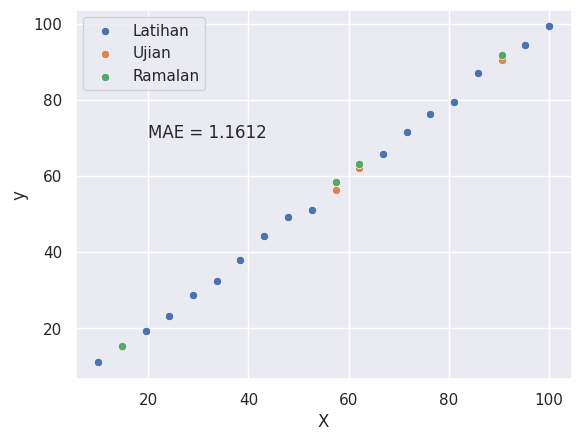

In [108]:
sns.scatterplot(x=X_latih, y=y_latih, label="Latihan")
sns.scatterplot(x=X_ujian, y=y_ujian, label="Ujian")
sns.scatterplot(x=X_ujian, y=y_pred.squeeze(), label="Ramalan")

plt.text(x=20, y=70, s=f'MAE = {mae_nn:.4f}')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

# Perbandingan Kaedah Conventional vs Neural Network

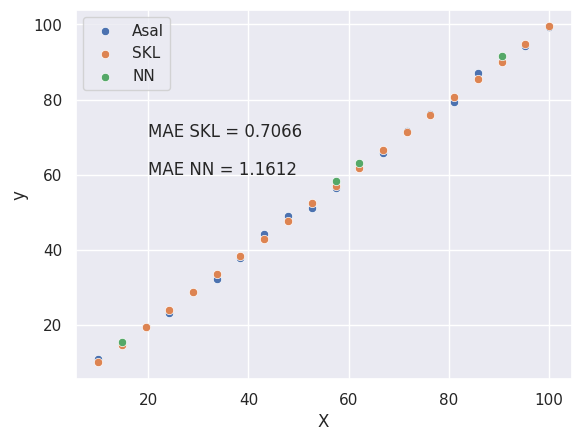

In [109]:
sns.scatterplot(x=X, y=y, label="Asal")
sns.scatterplot(x=X, y=y_skl_ramal, label="SKL")
sns.scatterplot(x=X_ujian, y=y_pred.squeeze(), label="NN")

plt.text(20, 70, f'MAE SKL = {mae_skl_lr:.4f}')
plt.text(20, 60, f'MAE NN = {mae_nn:.4f}')

plt.xlabel("X")
plt.ylabel("y")
plt.show()